In [24]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [25]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [26]:
len(x_train)

60000

In [27]:
len(x_test)

10000

In [28]:
x_train[0].shape

(28, 28)

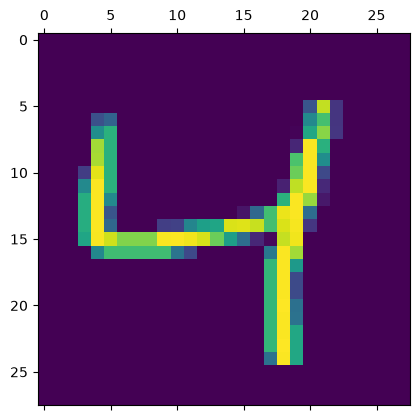

In [29]:
plt.matshow(x_train[2])

In [30]:
y_train[2]

np.uint8(4)

In [31]:
y_train[:9]

array([5, 0, 4, 1, 9, 2, 1, 3, 1], dtype=uint8)

In [32]:
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train_flattened=x_train.reshape(len(x_train),28*28)
x_test_flattened=x_test.reshape(len(x_test),28*28)

x_train_flattened.shape

(60000, 784)

In [33]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Fit the model
model.fit(x_train_flattened, y_train, epochs=5)

Epoch 1/5


c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8766 - loss: 0.4676
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9151 - loss: 0.3038
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9200 - loss: 0.2836
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9242 - loss: 0.2731
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9255 - loss: 0.2666


In [34]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9254 - loss: 0.2690


[0.26901763677597046, 0.9254000186920166]

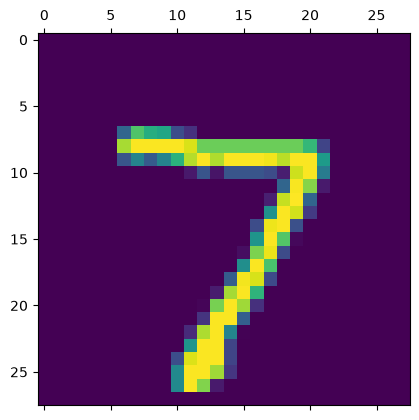

In [35]:
plt.matshow(x_test[0])

In [36]:
y_predicted=model.predict(x_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step


array([4.06735651e-02, 4.10953504e-07, 6.68587312e-02, 9.71578658e-01,
       3.48186702e-03, 1.05104864e-01, 1.03581476e-06, 9.99836266e-01,
       1.16766855e-01, 6.20624661e-01], dtype=float32)

In [37]:
np.argmax(y_predicted[0])

np.int64(7)

In [38]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [39]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [40]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 963,    0,    1,    2,    0,    4,    7,    2,    1,    0],
       [   0, 1109,    3,    2,    1,    1,    4,    2,   13,    0],
       [   6,    9,  926,   20,    9,    1,   12,    9,   37,    3],
       [   3,    0,   14,  939,    0,   16,    2,   10,   20,    6],
       [   2,    1,    2,    2,  929,    0,   11,    3,    9,   23],
       [  10,    3,    5,   49,   14,  749,   16,    8,   33,    5],
       [  12,    3,    7,    1,    7,    9,  915,    2,    2,    0],
       [   1,    5,   21,   11,    8,    0,    0,  954,    2,   26],
       [   7,    7,    6,   29,    9,   19,    9,   13,  869,    6],
       [  11,    7,    1,   13,   39,    6,    0,   25,    6,  901]],
      dtype=int32)>

Text(95.83333333333333, 0.5, 'Truth')

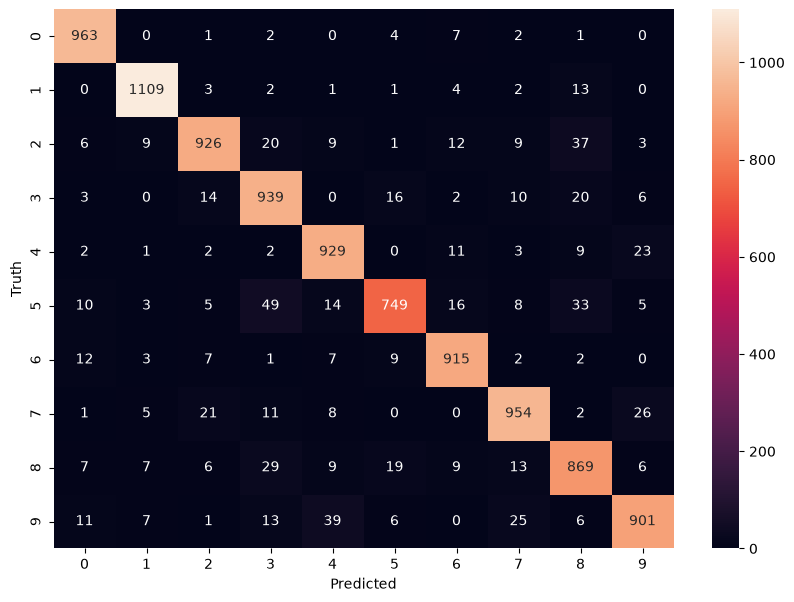

In [41]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [48]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])
tb_callbacks = tf.keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

model.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# 6. Fit the model
model.fit(x_train_flattened, y_train, epochs=5,callbacks=[tb_callbacks])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8298 - loss: 0.6654
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9040 - loss: 0.3445
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9166 - loss: 0.2968
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9247 - loss: 0.2679
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9308 - loss: 0.2462


In [49]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9347 - loss: 0.2294


[0.22942160069942474, 0.9347000122070312]

In [51]:
%load_ext tensorboard
%tensorboard --logdir logs
%reload_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 10060), started 0:00:45 ago. (Use '!kill 10060' to kill it.)